In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [4]:
# extract data from DMI API
url = "https://opendataapi.dmi.dk/v2/metObs/collections/observation/items"

params = {
    "stationId": "06180",
    "parameterId": "temp_dry",
    "datetime": "2024-06-01T00:00:00Z/2024-08-31T23:59:59Z",
    "limit": 20000
}

response = requests.get(url, params=params)
data = response.json()

print("Number of observations: " + str(len(data["features"])))

Number of observations: 13247


In [5]:
# parse data into a DataFrame
records = [feature["properties"] for feature in data["features"]]

df = pd.DataFrame(records)
df["observed"] = pd.to_datetime(df["observed"])
df = df.sort_values("observed").reset_index(drop=True)
df = df[["observed", "value"]].rename(columns={"value": "temp_c"})
df = df.set_index("observed")

print(df.shape)
df.head()

(13247, 1)


,temp_c
observed,
2024-06-01 00:00:00+00:00,15.8
2024-06-01 00:10:00+00:00,15.6
2024-06-01 00:20:00+00:00,15.5
2024-06-01 00:30:00+00:00,15.9
2024-06-01 00:40:00+00:00,16.2


In [6]:
# resample hourly averages
hourly = df.resample("H").mean()
hourly.columns = ["temp_c"]
hourly = hourly.dropna()

print(hourly.shape)
hourly.head()

(2208, 1)


C:\Users\45605\AppData\Local\Temp\ipykernel_11492\3257981978.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df.resample("H").mean()


,temp_c
observed,
2024-06-01 00:00:00+00:00,15.866667
2024-06-01 01:00:00+00:00,16.166667
2024-06-01 02:00:00+00:00,16.183333
2024-06-01 03:00:00+00:00,16.416667
2024-06-01 04:00:00+00:00,16.883333


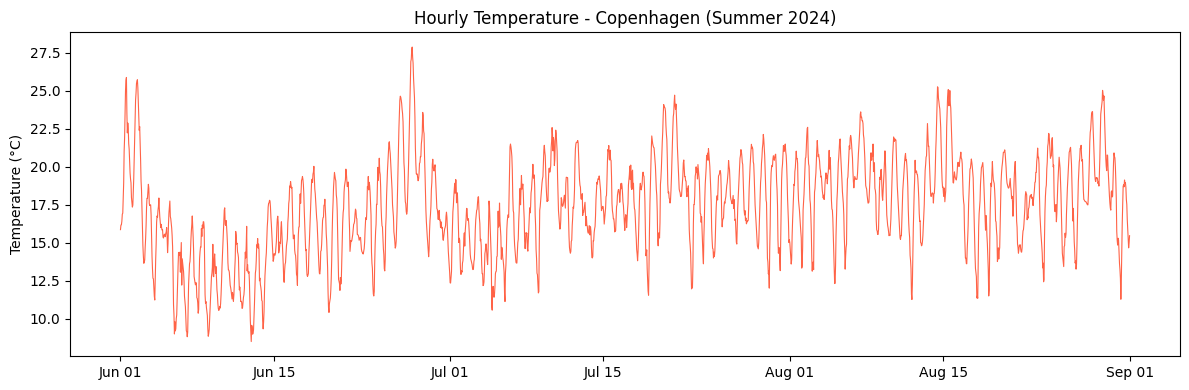

In [7]:
# quick plot of summer temperature series
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(hourly.index.tz_localize(None), hourly["temp_c"], 
        color="tomato", lw=0.8)

ax.set_title("Hourly Temperature - Copenhagen (Summer 2024)")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("")

import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
plt.show()

That's a great looking time series! A few things stand out:

- Clear daily cycles — the regular up-down rhythm of day/night temperature
- A warm peak around Jul 1 hitting nearly 28°C
- Cool spell in mid-June dropping to around 9-10°C
- Generally warmer and more stable in July-August

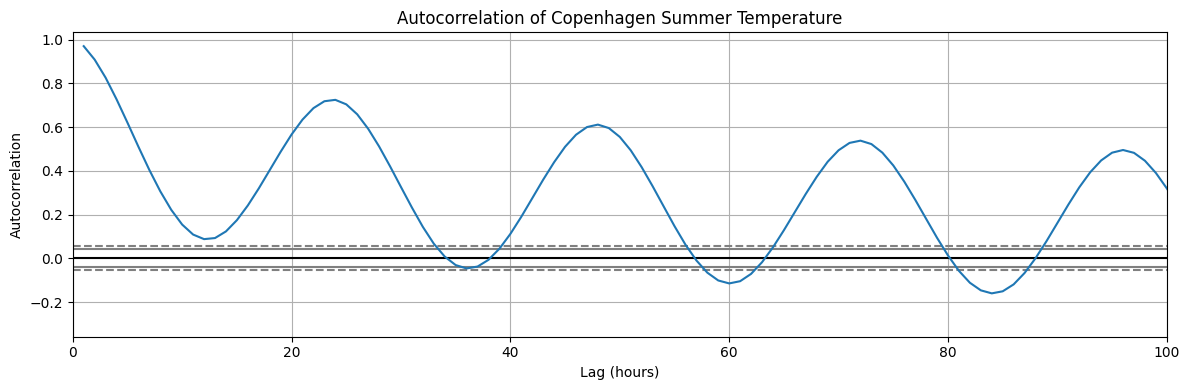

In [8]:
# compute + plot the autocorrelation 
from pandas.plotting import autocorrelation_plot

fig, ax = plt.subplots(figsize=(12, 4))

autocorrelation_plot(hourly["temp_c"], ax=ax)

ax.set_xlim(0, 100)  # look at first 100 lags (hours)
ax.set_title("Autocorrelation of Copenhagen Summer Temperature")
ax.set_xlabel("Lag (hours)")

plt.tight_layout()
plt.show()

comments:
- The autocorrelation starts at 1.0 (perfectly correlated with itself at lag 0)
- First zero crossing at around lag 6 — that's 6 hours, our optimal τ
- Then it peaks again at lag 24 — that's the daily cycle! Temperature at noon is strongly correlated with temperature at noon the next day
- The wave pattern slowly decays — the memory of the atmosphere fades over several days


That 24-hour periodicity is exactly what we saw visually in the time series — the daily rhythm of heating and cooling.


<b>Our lag τ = 6 hours.</b>

In [ ]:
# find the exact lag
# Extract autocorrelation values
temp = hourly["temp_c"].values
n = len(temp)

acf = [pd.Series(temp).autocorr(lag=i) for i in range(100)]

# Find first zero crossing
for i in range(1, len(acf)):
    if acf[i] < 0:
        print("First zero crossing at lag: " + str(i) + " hours")
        tau = i
        break

First zero crossing at lag: 35 hours


In [10]:
tau = 6
print("Using lag tau = " + str(tau) + " hours")

Using lag tau = 6 hours


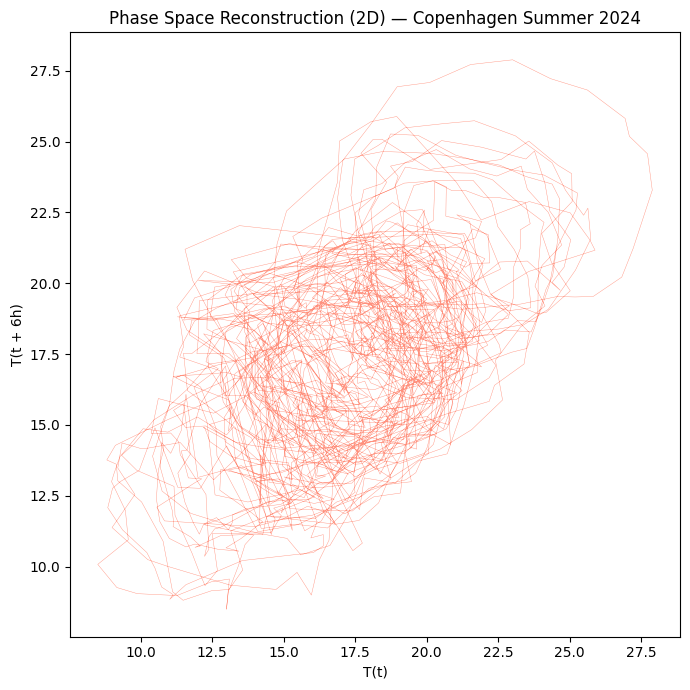

In [11]:
# Extract the temperature values as a numpy array
T = hourly["temp_c"].values

# Create time-delayed copies
T1 = T[:-2*tau]        # T(t)
T2 = T[tau:-tau]       # T(t + tau)
T3 = T[2*tau:]         # T(t + 2*tau)

# 2D phase space plot
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(T1, T2, lw=0.3, color="tomato", alpha=0.7)

ax.set_title("Phase Space Reconstruction (2D) — Copenhagen Summer 2024")
ax.set_xlabel("T(t)")
ax.set_ylabel("T(t + 6h)")

plt.tight_layout()
plt.show()

comments:
- The trajectory is not random — it has clear structure, concentrated in an elongated blob along the diagonal
- The diagonal orientation makes sense — if it's 20°C now, it's likely close to 20°C in 6 hours
- The spread around the diagonal represents the daily cycle pushing temperatures up and down
- It's not a clean closed loop like a simple periodic system, but it's not random scatter either — that's the signature of a chaotic but structured system

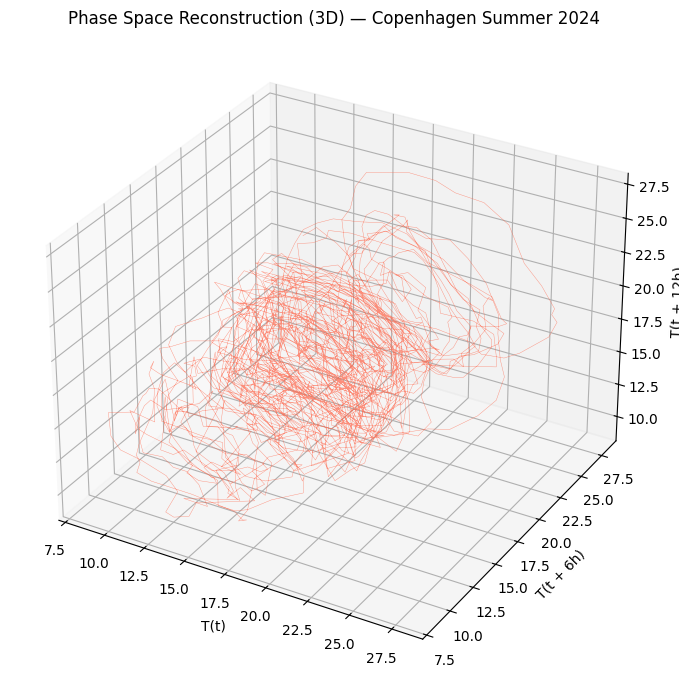

In [12]:
# now 3D
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(T1, T2, T3, lw=0.3, color="tomato", alpha=0.7)

ax.set_title("Phase Space Reconstruction (3D) — Copenhagen Summer 2024")
ax.set_xlabel("T(t)")
ax.set_ylabel("T(t + 6h)")
ax.set_zlabel("T(t + 12h)")

plt.tight_layout()
plt.show()

#### we created a strange attractor:
- The Lorenz attractor has two distinct wings — the system switches between two regimes
- Copenhagen attractor is more of a tangled blob — the atmosphere doesn't have such clean regime switching, it's messier
- Crucially it's not random — a random system would fill the box uniformly. This has clear structure concentrated in the centre